# Custom CNN Baseline for Binary Image Classification

## Overview
This notebook implements a custom CNN architecture with residual blocks and multi-scale feature extraction for binary image classification on an imbalanced dataset. The model uses weighted sampling to handle class imbalance and is evaluated with comprehensive metrics including ROC AUC.

---

## 1. Import Required Libraries

Import all necessary libraries for model building, data loading, training, and evaluation.

In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np

## 2. Configuration & Hyperparameters

Set up training configuration including batch size, number of epochs, learning rate, and device (GPU/CPU). 
Verify that the data directory exists.

In [ ]:
# =====================
# 1. CONFIG
# =====================

from pathlib import Path
DATA_DIR = "data"
FIXED_LR = 1e-4
BATCH_SIZES = [32, 64]  # Tuning batch sizes instead of LR
EPOCHS = 30
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


## 3. Define Data Transformations

Create data augmentation pipelines:
- **Train transforms**: Include augmentations (flip, rotation) to improve generalization
- **Val/Test transforms**: Only resize and convert to tensor (no augmentation for consistency)

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])



val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])


## 4. Define ResidualBlock Architecture

Implement a **Residual Block** with skip connections:
- Two convolution layers with batch normalization and ReLU activation
- Skip connection that adapts dimensions when stride > 1 or input/output channels differ
- Helps prevent vanishing gradients in deep networks

In [5]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)

## 5. Define Multi-Scale Block & Custom CNN Model

### MultiScaleBlock
Extracts features at multiple receptive field sizes (1x1, 3x3, 5x5 convolutions) and concatenates them. 
This captures features at different scales, improving feature representation.

### CustomCNN Architecture
- **Stem**: Initial convolution block with max pooling
- **Layer 1-2**: Residual blocks with increasing channels
- **MultiScale**: Multi-scale feature extraction
- **Layer 3**: Final residual block
- **FC Head**: Adaptive pooling + 2 fully connected layers for binary classification (outputs single sigmoid-compatible value)

Instantiate and move model to device.

In [6]:
class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1)
        self.conv3 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.conv5 = nn.Conv2d(in_channels, out_channels, 5, padding=2)

    def forward(self, x):
        return torch.cat([
            self.conv1(x),
            self.conv3(x),
            self.conv5(x)
        ], dim=1)

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, 7, stride=2, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(3, stride=2, padding=1)
        )

        self.layer1 = ResidualBlock(32, 32)
        self.layer2 = ResidualBlock(32, 64, stride=2)

        self.multi = MultiScaleBlock(64, 32)  # output = 96 channels

        self.layer3 = ResidualBlock(96, 128, stride=2)

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.multi(x)
        x = self.layer3(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

model = CustomCNN().to(DEVICE)


## 7. Define Loss Function & Optimizer

- **Loss**: BCEWithLogitsLoss with `pos_weight` to handle class imbalance (weighted loss for minority class)
- **Optimizer**: AdamW with L2 regularization (weight decay)

The pos_weight balances the contribution of positive (minority) class samples in the loss.

## 8. Define Training & Evaluation Functions

### train_epoch()
One training epoch: forward pass, compute loss, backward pass, optimizer step.
Returns average loss and accuracy.

### eval_epoch()
Evaluate on validation/test set without updating model weights.
Returns loss, accuracy, and prediction probabilities for further analysis (e.g., ROC-AUC).

In [7]:
def train_epoch(loader):
    model.train()
    total_loss, correct = 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (torch.sigmoid(out) > 0.5).float()
        correct += (preds == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(loader):
    model.eval()
    total_loss, correct = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.float().unsqueeze(1).to(DEVICE)
            out = model(x)
            loss = criterion(out, y)

            total_loss += loss.item()
            preds = torch.sigmoid(out)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            binary = (preds > 0.5).float()
            correct += (binary == y).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset), np.array(all_preds), np.array(all_labels)

## 9. Train Model for Multiple Epochs

Run training loop for specified number of epochs:
- Train on training set with augmentation and weighted sampling
- Evaluate on validation set
- Save model checkpoint after each epoch
- Print training progress (loss and accuracy)
- Save final model state

In [9]:
batch_histories = {}
os.makedirs("batch_tuned_models", exist_ok=True)

for bs in BATCH_SIZES:
    print(f"\n--- Starting Training with Batch Size: {bs} ---")
    
    # Update DataLoaders for the new batch size
    train_loader = DataLoader(train_dataset, batch_size=bs, sampler=sampler, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False, num_workers=2)
    
    # Re-initialize model, loss, and optimizer
    model = CustomCNN().to(DEVICE)
    pos_weight = torch.tensor([class_count[0] / class_count[1]]).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=FIXED_LR, weight_decay=1e-4)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    
    # --- Track the best validation accuracy for this batch size ---
    best_val_acc = 0.0
    model_save_path = f"batch_tuned_models/model_bs_{bs}.pth"
    
    for epoch in range(EPOCHS):
        tl, ta = train_epoch(train_loader)
        vl, va, _, _ = eval_epoch(val_loader)

        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        # --- Save the model ONLY if validation accuracy improves ---
        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), model_save_path)
            print(f"--> New best model saved at Epoch {epoch+1} with Val Acc: {va:.4f}")

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{EPOCHS}: Train Loss {tl:.4f}, train acc:{ta:.4f}, Val Acc {va:.4f}")

    batch_histories[bs] = history

print("\n--- Batch Size Tuning Complete ---")


--- Starting Training with Batch Size: 32 ---
--> New best model saved at Epoch 1 with Val Acc: 0.0500
Epoch 1/30: Train Loss 2.2675, train acc:0.5016, Val Acc 0.0500
--> New best model saved at Epoch 5 with Val Acc: 0.0550
Epoch 5/30: Train Loss 1.7364, train acc:0.4909, Val Acc 0.0550
--> New best model saved at Epoch 6 with Val Acc: 0.0580
--> New best model saved at Epoch 7 with Val Acc: 0.1780
Epoch 10/30: Train Loss 1.5097, train acc:0.5514, Val Acc 0.1070
--> New best model saved at Epoch 11 with Val Acc: 0.3080
--> New best model saved at Epoch 15 with Val Acc: 0.3850
Epoch 15/30: Train Loss 1.2753, train acc:0.6439, Val Acc 0.3850
--> New best model saved at Epoch 17 with Val Acc: 0.4860
--> New best model saved at Epoch 20 with Val Acc: 0.6300
Epoch 20/30: Train Loss 1.0723, train acc:0.7201, Val Acc 0.6300
--> New best model saved at Epoch 21 with Val Acc: 0.6570
Epoch 25/30: Train Loss 0.9031, train acc:0.7718, Val Acc 0.6260
Epoch 30/30: Train Loss 0.8452, train acc:0.789

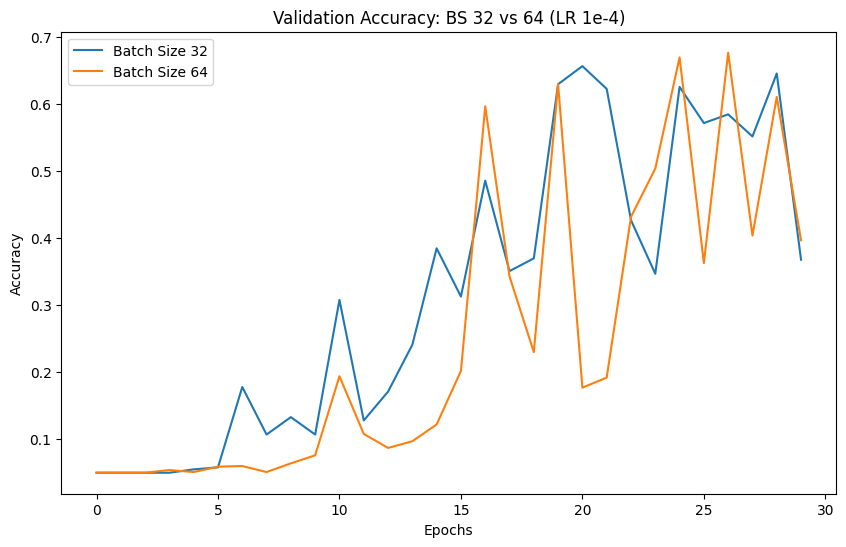

In [10]:
plt.figure(figsize=(10, 6))
for bs, hist in batch_histories.items():
    plt.plot(hist['val_acc'], label=f'Batch Size {bs}')

plt.title("Validation Accuracy: BS 32 vs 64 (LR 1e-4)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [15]:
from sklearn.metrics import f1_score, average_precision_score, accuracy_score
import pandas as pd

model_dir = "tuned_models"
batch_model_dir = "batch_tuned_models"
test_results = []

# List of configurations to check
configs = [
    {"name": "BS 32 (LR 1e-4)", "path": f"batch_tuned_models/model_bs_32.pth"},
    {"name": "BS 64 (LR 1e-4)", "path": f"batch_tuned_models/model_bs_64.pth"},
]

for config in configs:
    if os.path.exists(config["path"]):
        # Load Model
        model = CustomCNN().to(DEVICE)
        model.load_state_dict(torch.load(config["path"]))
        
        # Get Predictions
        test_dataset = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_transform)
        test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
        _, _, test_probs, test_labels = eval_epoch(test_loader)
        test_preds_binary = (test_probs > 0.5).astype(int)
        
        # Calculate Metrics
        acc = accuracy_score(test_labels, test_preds_binary)
        auroc = roc_auc_score(test_labels, test_probs)
        f1 = f1_score(test_labels, test_preds_binary)
        ap = average_precision_score(test_labels, test_probs)
        
        test_results.append({
            "Model Config": config["name"],
            "Overall Accuracy": f"{acc:.4f}",
            "AUROC": f"{auroc:.4f}",
            "F1-Score": f"{f1:.4f}",
            "Avg Precision": f"{ap:.4f}"
        })

# Display Results
results_df = pd.DataFrame(test_results)
print("\n--- Detailed Model Performance Comparison ---")
print(results_df.to_string(index=False))


--- Detailed Model Performance Comparison ---
   Model Config Overall Accuracy  AUROC F1-Score Avg Precision
BS 32 (LR 1e-4)           0.6570 0.8341   0.1853        0.2924
BS 64 (LR 1e-4)           0.6600 0.8365   0.1827        0.3104
